In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data,columns=iris.feature_names)
y = pd.Series(iris.target,name='species')

In [3]:
X.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
target_mapping = {i:str(name) for i,name in enumerate(iris.target_names)}
target_mapping

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}

In [5]:
X_df = pd.DataFrame(X,columns=X.columns)
X_df['actual species'] = y
X_df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [6]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   actual species     150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
X_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
y_train_predict = knn.predict(X_train_scaled)
y_test_predict = knn.predict(X_test_scaled)

In [12]:
# Accuracy Score :
print(f"Accuracy in train : {accuracy_score(y_train,y_train_predict)}")
print(f"Accuracy in test : {accuracy_score(y_test,y_test_predict)}")

Accuracy in train : 0.975
Accuracy in test : 0.9333333333333333


In [13]:
knn2 = KNeighborsClassifier(n_neighbors=11)
knn2.fit(X_train_scaled,y_train)
y_train_predict2 = knn2.predict(X_train_scaled)
y_test_predict2 = knn2.predict(X_test_scaled)
# Accuracy Score :
print(f"Accuracy in train : {accuracy_score(y_train,y_train_predict2)}")
print(f"Accuracy in test : {accuracy_score(y_test,y_test_predict2)}")     # we see the greater the n_neighbors is the better the test result

Accuracy in train : 0.9583333333333334
Accuracy in test : 0.9666666666666667


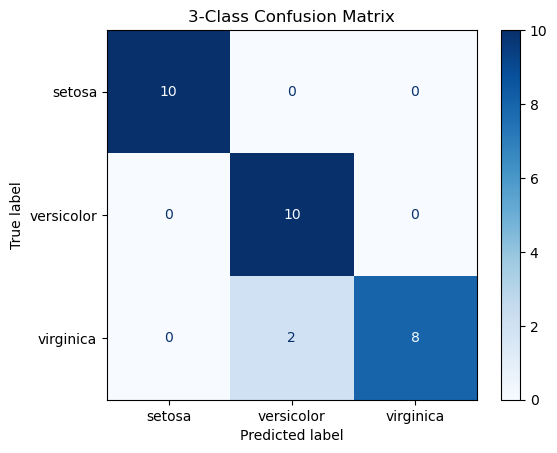

In [14]:
cm = confusion_matrix(y_test,y_test_predict)
cm2 = confusion_matrix(y_test,y_test_predict2)

def confusion_matrix_display(cm_):
    target_names = iris.target_names
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_,display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)

    # 5. Show plot
    plt.title("3-Class Confusion Matrix")
    plt.show()

confusion_matrix_display(cm)

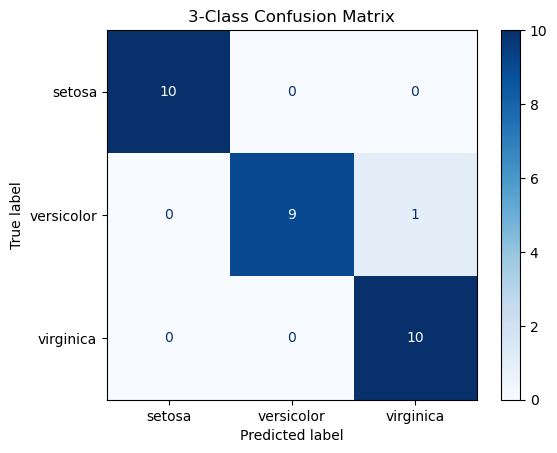

In [15]:
confusion_matrix_display(cm2)

## The Elbow Method :
- The Elbow Method is a visual heuristic used to determine the optimal number of clusters (K) in unsupervised learning algorithms, most notably K-Means Clustering. 


In [36]:
accuracy_test = []
error_rates = []
K_range = range(1,21)

for k in K_range:
    knn_ = KNeighborsClassifier(n_neighbors=k)
    knn_.fit(X_train_scaled,y_train)
    y_pred = knn_.predict(X_test_scaled)
    accuracy_ = accuracy_score(y_test,y_pred)
    error_ = np.mean(y_pred != y_test) 
    # error_ = 1 - accuracy_
    accuracy_test.append(accuracy_)
    error_rates.append(error_)
    
# print(error_,'\n',error_1)

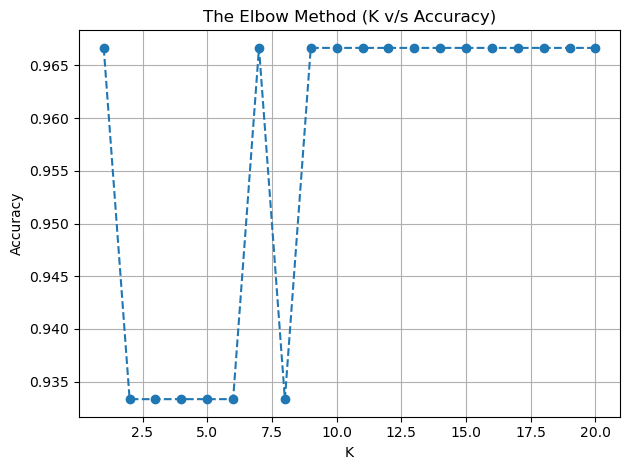

In [17]:
plt.figure(12)
plt.title("The Elbow Method (K v/s Accuracy)")
plt.plot(K_range,accuracy_test,marker="o",linestyle='--')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.grid(True)
plt.show()

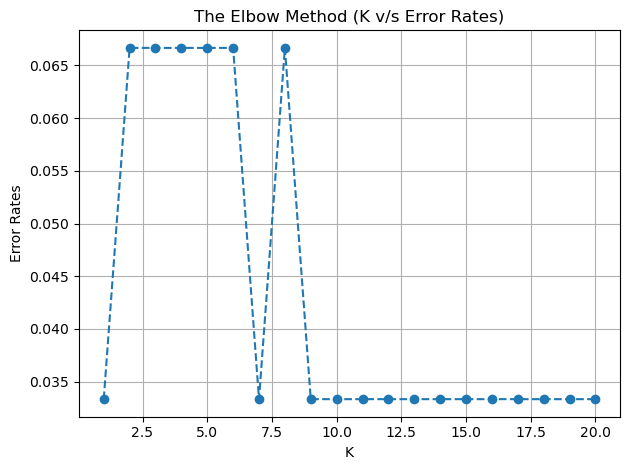

In [18]:
plt.figure(12)
plt.title("The Elbow Method (K v/s Error Rates)")
plt.plot(K_range,error_rates,marker="o",linestyle='--')
plt.xlabel("K")
plt.ylabel("Error Rates")
plt.tight_layout()
plt.grid(True)
plt.show()

### Cross validation to find the best value of K : 

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
cv_scores = [] 
K_range = range(1,21)
for i in K_range:
    _knn_ = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(_knn_,X_scaled,y,cv=10,scoring='accuracy')
    print(f"Nearest Neighbor selected : {i} | mean score : {round(scores.mean(),5)}  | Scores for each fold {scores}")
    cv_scores.append(scores.mean())

Nearest Neighbor selected : 1 | mean score : 0.95333  | Scores for each fold [1.         0.93333333 1.         0.93333333 0.86666667 1.
 0.8        1.         1.         1.        ]
Nearest Neighbor selected : 2 | mean score : 0.95333  | Scores for each fold [1.         0.93333333 1.         0.93333333 0.86666667 1.
 0.8        1.         1.         1.        ]
Nearest Neighbor selected : 3 | mean score : 0.95333  | Scores for each fold [1.         0.93333333 1.         0.93333333 0.86666667 1.
 0.8        1.         1.         1.        ]
Nearest Neighbor selected : 4 | mean score : 0.94667  | Scores for each fold [1.         0.93333333 1.         0.93333333 0.93333333 1.
 0.8        0.93333333 1.         0.93333333]
Nearest Neighbor selected : 5 | mean score : 0.95333  | Scores for each fold [1.         0.93333333 1.         0.93333333 0.86666667 0.93333333
 0.86666667 1.         1.         1.        ]
Nearest Neighbor selected : 6 | mean score : 0.96667  | Scores for each fold [1.  

In [21]:
best_k = K_range[np.argmax(cv_scores)]
print(f"Best K using Cross Validation: {best_k}")
print(f"Cross-validation accuracy for K={best_k}: {max(cv_scores):.4f}")

Best K using Cross Validation: 8
Cross-validation accuracy for K=8: 0.9667


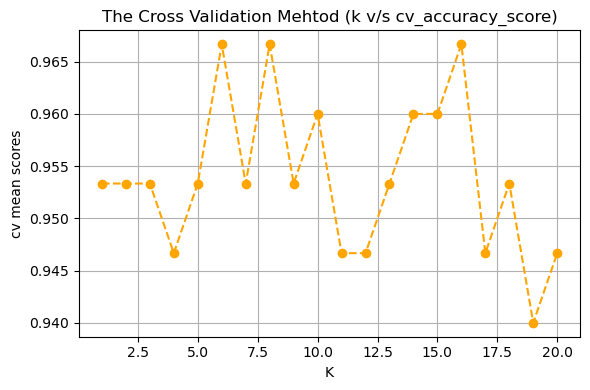

In [22]:
plt.figure(figsize=(6,4))
plt.title("The Cross Validation Mehtod (k v/s cv_accuracy_score)")
plt.plot(K_range,cv_scores,marker="o",linestyle='--',color='orange')
plt.xlabel("K")
plt.ylabel("cv mean scores")
plt.tight_layout()
plt.grid(True)
plt.show()

In [23]:
def confusion_matrix_display(cm_):
    target_names = iris.target_names
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_,display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)

    # 5. Show plot
    plt.title("3-Class Confusion Matrix")
    plt.show()

In [24]:
def predict_iris(sp_len,sp_wid,pt_len,pt_wid):
    sample_df = pd.DataFrame([[sp_len,sp_wid,pt_len,pt_wid]],columns=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)','petal width (cm)'])
    scaled = scaler.transform(sample_df)
    prediction = knn.predict(scaled)[0] # it will return the encoded value
    prediction2 = knn2.predict(scaled)[0]
    model_predictions = { 'kNN (k=5)':target_mapping[prediction],'kNN2 (k=11)':target_mapping[prediction2] }
    return model_predictions

predict_iris(6.7,3.0,5.2,2.3)

{'kNN (k=5)': 'virginica', 'kNN2 (k=11)': 'virginica'}

- But in the above cross validation method i found that for K = 8 my model has generates a great accuracy scores

In [25]:
k = 8
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled,y_train)

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_train_pred_8 = knn.predict(X_train_scaled)
y_test_pred_8 = knn.predict(X_test_scaled)

def predict_irisX(sepal_length, sepal_width, petal_length, petal_width):
    sample_df = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]], columns=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])
    sample_scaled = scaler.transform(sample_df)
    prediction = knn.predict(sample_scaled)[0]
    predicted_species = iris.target_names[prediction]
    return predicted_species, prediction

In [27]:
predictions = []
pred_idx = []

for i in X.values:
    cur_pred,predicted_idx = predict_irisX(i[0],i[1],i[2],i[3])
    predictions.append(cur_pred)
    pred_idx.append(predicted_idx)

X_df["predicted species"]  = predictions
X_df["predicted species idx"] = pred_idx

X_df.to_csv("predicted_answer.csv")

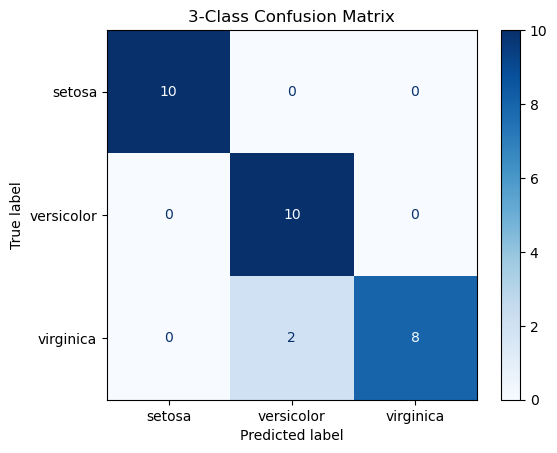

In [28]:
cm8_test = confusion_matrix(y_test,y_test_pred_8)
confusion_matrix_display(cm8_test)

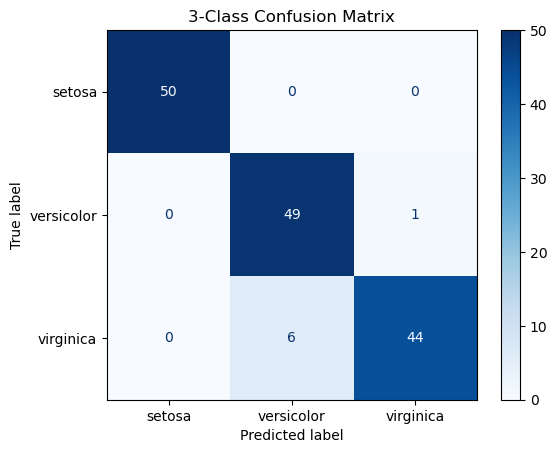

In [29]:
# For whole dataset our prediction : 
cm8_df = confusion_matrix(X_df['actual species'],X_df['predicted species idx'])
confusion_matrix_display(cm8_df)